# **Computer Vision Final Project**
By Selin Ozgur


## **Executive Summary**

The majority of urinary tract infections (UTI's) in humans are caused by uropathogenic *E.coli*. To study the mechanisms of urinary tract infections and evaluate potential drug treatments, scientists often use cell culture systems or mouse models to replicate the disease. Mice models are costly to maintain and often require the sacrifice of the animal, cell cultures on the other hand do not give us any context on what may be happening in multiple tissues or in the whole organism.

*C. elegans* is a transparent, microscopic worm that could potentially be used to study urinary tract infections. *C. elegans* can be infected by many human pathogens including uroptahogenic *E.coli* strains. The worms digest the UTI strains which maintain an infection within the worm gut, causing colonization and gut distention which can be easily imaged under the microscope.

The main objective of this project is to generate a generate and train a classsifying model model that an recognize between infected and uninfected adult worms. The Systematic Imaging of Caenorhabditis Killing Organisms (SICKO) dataset contains microscopy images of worms fed on fluorescently tagged control (OP50) and pathogen (PA14) bacterial strains. If a bacteria is able to colonize the worm, the gut will have a fluorescence signal.

## **Objective:** Using the Systematic Imaging of Caenorhabditis Killing Organisms (SICKO) dataset to classify infection severity of pathogens in worm guts.  

# **Data Set:**

**Description:** This is a C. elegans dataset used to test and validate the Systematic Imaging of Caenorhabditis Killing Organisms (SICKO) imaging and analysis pipeline. The dataset consists of raw TIF image files containing fluorescent images of individual *C. elegans* cultured in custom single-worm culture environments (DOI: 10.3791/64682). Wild type (strain N2) C. elegans were challenged with either GFP-labeled E. coli OP50 or mScarlet-labeled P. aeruginosa bacteria, washed to remove non-adherent bacteria, and transferred to single-worm culture environment wells with unlabeled bacteria. Each worm was imaged daily to quantify fluorescent intestinal bacterial colonies.

**Download link:** https://arizona.figshare.com/articles/dataset/_i_C_elegans_i_bacteria_colonization_data_set_Wild_type_N2_worms_colonized_with_GFP-labeled_E_coli_OP50_vs_mScarlet-labeled_P_aeruginosa_PA14/25749372

**Unzipping:** The data needs to be unzipped using the 7z x GOP50_RPA14_N2.zip command or it becomes corrupted.

**Challenges:** There are some challenges with this dataset. The images are not properly labeled. The data is split into two groups across multiple days and is categorized in folders instead of proper labeling. Also the zip file is very disorganized and does not have a README that explains the organization of the data so it took me a significant amount of time to understand it. The images are in a raw TIFF format and it is hard to manually go through the individual images for quality control without the help of imageJ, and even then they are grey scale so manual quality control steps are time consuming and hard to judge by human eye. This was also not mention in the documentation of the dataset but there are 3 consecutivly taken pictures of each worm that look very similar, so it is important to keep this in mind while training the model.

**Dealing with computational limitations:** This is a quite large dataset with thousands of TIFF files. I have uploaded the dataset into google drive and will be using google colab for this project. I will attempt to avoid repeatedly moving files through drive during training because google recommends reducing read/write operations from mounted drive. Training the model with files on the drive is very time consuming, so the files need to be moved to colab SSD before model training and whenever google colab has a timeout.

# **Project Pipeline**

**Step 1 (EDA and labeling the data):** Since the dataset is very disorganized I had to spend a considerable amount of time to label the images. There is next to no information about the organization of the files and there are thousands of unlabeled files that I omitted. I assigned labels to files based on the folder structure. Folders were organized in pathogen vs non-pathogen, biological replicate (1,2,3) and days of treatment, along with well numbers that indicate the name of the single worm in the image. I've created a metadata.csv file with labels extracted from the path of each image and used this file to assign the images into the right groups.

**Step 2: (Image processing)** When I looked at the two different groups of images, I coul see that were a lot of differences in background, so the model could technically learn to recognize the background to classify the image as 'pathogenic'.To overcome this I normalized the backgrounds and used a circular mask to exclude the area that is outside of the 96-well plate and had no information. I also chose to change the dimensions of the images from 1024x 1024 to 512x 512 because it was very time consuming to process such large images and changing the shape to 512 x512 had no effect on the context based biological information in the images.

Step 3: (**Data augmentation**) There are approximately 3 biological replicates x ~280 images per day (9 days) per group (2) variable across some days, 280 x 9x 2= ~5000x 3= ~15000 images. All the images were taken with the same microscope and the orientation is different across images but I needed data augmentation for this dataset. The contrast and brightness is very different between the control and pathogen treated images. I used the following augmentation methods: Random flip, random rotation, random zoom, random contrast, rndom brightness, random contrast and gamma augmentation.

**Step 4: (Deciding on the Training Set)** Deciding on how to split the trainins dataset ended up being very importatn for this project. There are 3 biological replicates of 9 days of treatement in this data. By day 9, a significant portion of worms die, therefore there is some imbalance in how often treatment days are represented in the dataset. There are also slight differences in how the wells are aligned and how bright they look depending on the biological replicate. And lastly, there are 3 consecutive pictures of each individual worm for every treatment day per biological replicate. The pictures are very similar with maybe slight difference in worm orientation, so there is a significant amount of redundance in the dataset. I initially started my training by splitting the entire dataset without any consideration to these problems and then tried a bunch of new ways to to split to training dataset to improve the model's performance.

**Step 5: (Models)** I started the project off with a simple sequential binary classifier CNN and used this model to improve the design of the training set. Then I used the same training set on an efficient Net model to see if the my learning could be improved.

**Step 6 (Evaluate models):** I evaluated each model by comparing model metrics, accuracy/loss plots and confidence matrices.  

# **Google Drive/Colab Setup for Data**

It took more than 10 hours to upload the dataset to google drive so it is important remember the limitations of a dataset this size and plan accordingly

In [12]:
from google.colab import drive
#this connects drive to colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
#data path

from pathlib import Path

DATA_FOLDER= Path("/content/drive/MyDrive/Computer_Vision_Project_Data/project")

#Verify colab can see the foler
print(DATA_FOLDER.exists())
print(list(DATA_FOLDER.iterdir())[:5])


True
[PosixPath('/content/drive/MyDrive/Computer_Vision_Project_Data/project/GOP50_RPA14_N2 SICKO Coefficient Values.xlsx'), PosixPath('/content/drive/MyDrive/Computer_Vision_Project_Data/project/10a003.tif'), PosixPath('/content/drive/MyDrive/Computer_Vision_Project_Data/project/10b003.tif'), PosixPath('/content/drive/MyDrive/Computer_Vision_Project_Data/project/10a002.tif'), PosixPath('/content/drive/MyDrive/Computer_Vision_Project_Data/project/10a001.tif')]


There are 3 biological replicates per condition group (RPA14-Pathogen fed vs GOP50-Control fed worms) in this data. Naming each in detail in case there are discreptancies between replicates or conditions.

In [14]:
#Assign names to different categories and replicates of data
BASE_FOLDER = DATA_FOLDER / "GOP50_RPA14_N2 - Pooled"

control_data_rep1 = BASE_FOLDER / "Repeat 1" / "GOP50"
control_data_rep2 = BASE_FOLDER / "Repeat 2" / "GOP50"
control_data_rep3 = BASE_FOLDER / "Repeat 3" / "GOP50"

pathogen_data_rep1 = BASE_FOLDER / "Repeat 1" / "RPA14"
pathogen_data_rep2 = BASE_FOLDER / "Repeat 2" / "RPA14"
pathogen_data_rep3 = BASE_FOLDER / "Repeat 3" / "RPA14"


#Confirm folders exist
print(control_data_rep1.exists())
print(pathogen_data_rep1.exists())


True
True


# **EDA**

Here is a quick EDA to show the quality of the dataset I am working with.

In [15]:
# count tiff files
# each rep x condition has 9 days of data, every day has its own folder inside this folder

from pathlib import Path
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pandas as pd

all_paths = {
    ("GOP50", 1): control_data_rep1,
    ("GOP50", 2): control_data_rep2,
    ("GOP50", 3): control_data_rep3,
    ("RPA14", 1): pathogen_data_rep1,
    ("RPA14", 2): pathogen_data_rep2,
    ("RPA14", 3): pathogen_data_rep3,
}

summary = []

for (condition, replicate), folder_path in all_paths.items():
    for day_folder in sorted(folder_path.iterdir()):
        if day_folder.is_dir():
            tiff_files = (
                list(day_folder.rglob("*.tif")) +
                list(day_folder.rglob("*.tiff"))
            )

            summary.append({
                "condition": condition,
                "replicate": replicate,
                "day_folder": day_folder.name,
                "n_images": len(tiff_files)
            })

eda_df = pd.DataFrame(summary)

print(eda_df)

   condition  replicate                        day_folder  n_images
0      GOP50          1  2023_03_16_16_10_14--N2_GOP50_D1       288
1      GOP50          1  2023_03_17_13_06_39--N2_GOP50_D2       288
2      GOP50          1  2023_03_18_13_31_14--N2_GOP50_D3       288
3      GOP50          1  2023_03_19_14_17_40--N2_GOP50_D4       270
4      GOP50          1  2023_03_20_09_34_50--N2_GOP50_D5       270
5      GOP50          1  2023_03_21_10_05_25--N2_GOP50_D6       258
6      GOP50          1  2023_03_22_11_42_05--N2_GOP50_D7       249
7      GOP50          1  2023_03_23_11_23_15--N2_GOP50_D8       240
8      GOP50          1  2023_03_24_11_29_54--N2_GOP50_D9       234
9      GOP50          2  2023_04_13_13_49_57--N2_GOP50_D1       279
10     GOP50          2  2023_04_14_11_22_44--N2_GOP50_D2       279
11     GOP50          2  2023_04_15_19_00_53--N2_GOP50_D3       270
12     GOP50          2  2023_04_16_14_48_31--N2_GOP50_D4       213
13     GOP50          2  2023_04_17_12_03_49--N2

In [16]:
#summarize total image counts per replicate per group
eda_df.groupby(["condition", "replicate"])["n_images"].sum()

condition  replicate
GOP50      1            2385
           2            1590
           3            2178
RPA14      1            1740
           2            1635
           3            1836
Name: n_images, dtype: int64

There are some variation in image numbers. For example rep2 of OP50 control has a lot fewer pictures compared to the other replicates. There tends to be fewer pictures on day 9 for every replicate in every group, probably because not all worms survived for that long. Most importantly the pathogen pictures are a lot fewer than OP50 control and the control pictures are dominating this dataset. Fewer pictures in pathogen fed worms is most likely due to more worms being dead.

In [17]:
#check the size and type of images
from tifffile import imread
import pandas as pd

image_info = []

for (condition, replicate), folder_path in all_paths.items():

    # grab first tif image found recursively
    tif_files = (
        list(folder_path.rglob("*.tif")) +
        list(folder_path.rglob("*.tiff"))
    )

    if len(tif_files) > 0:

        img_path = tif_files[0]

        img = imread(img_path)

        image_info.append({
            "condition": condition,
            "replicate": replicate,
            "file_name": img_path.name,
            "shape": img.shape,
            "dtype": img.dtype,
            "min_pixel": img.min(),
            "max_pixel": img.max()
        })

image_info_df = pd.DataFrame(image_info)

print(image_info_df)

  condition  replicate   file_name         shape   dtype  min_pixel  max_pixel
0     GOP50          1  10c001.tif  (2048, 2048)  uint16        136       1144
1     GOP50          2  11d002.tif  (2048, 2048)  uint16        151       1916
2     GOP50          3  10a002.tif  (2048, 2048)  uint16        143       2748
3     RPA14          1  10a001.tif  (2048, 2048)  uint16         44        862
4     RPA14          2  10f002.tif  (2048, 2048)  uint16         51        610
5     RPA14          3  10a001.tif  (2048, 2048)  uint16         42        837


# Save data in a more usable format

Accessing images from the google drive takes a very long time and re-running the entire script each time google colab runs out is very inefficient and time consuming so I initially tried saving the entire dataset in the colab SSD for better speed, but saving from drive to ssd turned out to be a very long process so it doesn't make sense to do it each time the script runs out. For now I will access the dataset through google drive but I will save the images in 512x 512 instead of 2048x2048 because the original images are very hard to work with. I will also make a metadata csv that I could grab from the drive later on.

These images are not labeled but there are dates on them, it would be useful to label day of experiment so I will extract that information into the metadata file as well.


In [22]:
#make a metadata table
metadata = []

for (condition, replicate), folder_path in all_paths.items():

    label = 0 if condition == "GOP50" else 1

    tif_files = sorted(
        list(folder_path.rglob("*.tif")) +
        list(folder_path.rglob("*.tiff"))
    )

    for img_path in tif_files:

        day_folder = img_path.parent.name

        # extract D1, D2, etc.
        day = day_folder.split("_")[-1]

        metadata.append({
            "path": str(img_path),
            "condition": condition,
            "replicate": replicate,
            "label": label,
            "day_folder": day_folder,
            "day": day,
            "file_name": img_path.name
        })

metadata_df = pd.DataFrame(metadata)

#NEED TO SAVE TO DRIVE not SSD, SSD disappears.

metadata_df.to_csv(
    DRIVE_FOLDER / "image_metadata.csv",
    index=False
)

metadata_df.head()

,path,condition,replicate,label,day_folder,day,file_name
0,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10a001.tif
1,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10a002.tif
2,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10a003.tif
3,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10b001.tif
4,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10b002.tif


In [24]:
#check that day is extracted right
metadata_df[["day_folder", "day"]].head(20)
print(sorted(metadata_df["day"].unique()))

['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9']


Folder names had D1, D2, etc day labels so it worked.

In [ ]:
#USE THIS TO SAVE THINGS TO DRIVE PERIODICALLY
#ONLY RUN WHEN YOU WANT TO SAVE
#np.save("/content/drive/MyDrive/Computer_Vision_Project_Data/project/X_processed.npy",X)

#use this format saving models
#model.save("/content/drive/MyDrive/Computer_Vision_Project_Data/project/model.keras")

In [ ]:
# To reload the metadata CSV from drive
metadata_df = pd.read_csv(
    "/content/drive/MyDrive/Computer_Vision_Project_Data/project/image_metadata.csv"
)

# Image Pre-Processing

Here is what the raw images from each category look at the moment. I wanted to show images from the first day because they are more likely to have live worms. Dead worms could still have fluorescence because they only fluorescently tagged the bacteria and fed them to worms, but dead worms could have less gut integrity which will impact the fluoresence signal.


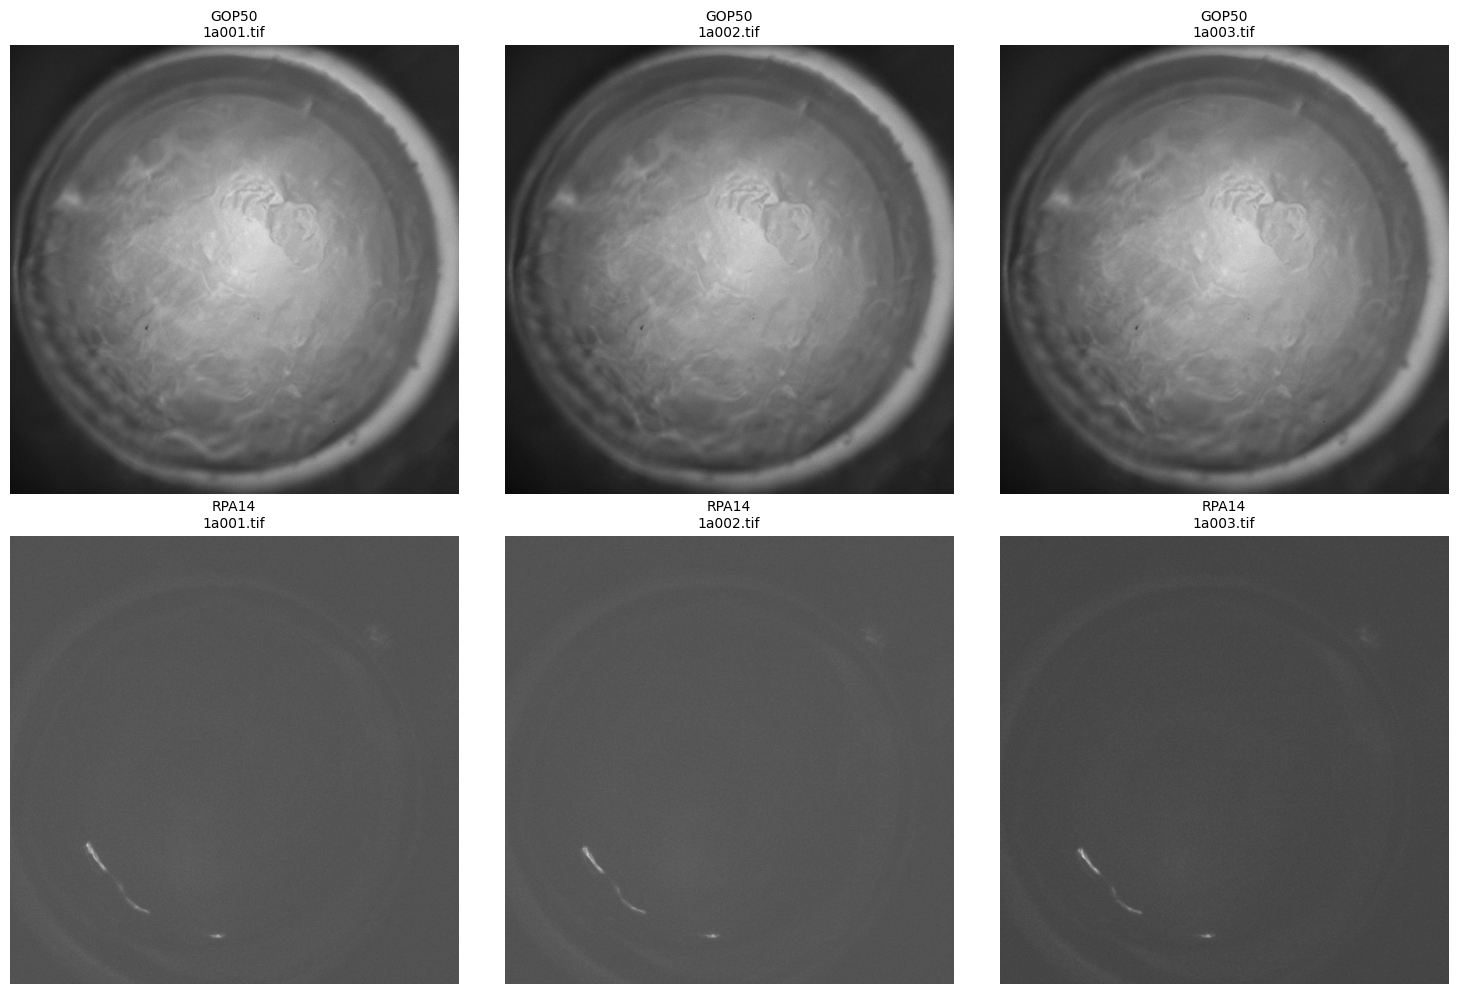

In [26]:
from tifffile import imread
import matplotlib.pyplot as plt
import numpy as np

from natsort import natsorted
from tifffile import imread
import matplotlib.pyplot as plt

# show 3 images from each condition
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

conditions_to_plot = {
    "GOP50": control_data_rep1,
    "RPA14": pathogen_data_rep1
}

for row_idx, (condition, folder_path) in enumerate(conditions_to_plot.items()):

    # get tif files with natural sorting
    tif_files = natsorted(
        list(folder_path.rglob("*.tif")) +
        list(folder_path.rglob("*.tiff"))
    )

    # take first 3 images
    selected_files = tif_files[:3]

    for col_idx, img_path in enumerate(selected_files):

        # load raw image
        img = imread(img_path)

        # plot RAW image
        axes[row_idx, col_idx].imshow(img, cmap="gray")

        axes[row_idx, col_idx].set_title(
            f"{condition}\n{img_path.name}",
            fontsize=10
        )

        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

We can easily see that there are very obvious differences between pictures from two categories. I also checked a bunch of random images from each group to make sure this was always the case. The control wells are much brighter and the intensity ranges between the images are very different (uint16 145 1215 vs uint16 47 214). There are also very obvious background problems between the two datasets, and we can see the outline of wells which probably need to be cropped out.

It is also especially apparent in the control images that a lot of the times it is very hard to differentiate between the worm and the tracks the worm leaves on the agar plate. I looked at many pictures to see if this was always the case, and it's not. In most pictures you can clearly spot the worm due to autofluorescence but there will always be the occasional picture like these where the difference between the worm and the worm tracks are very small. Healthy worms are not supposed to be colonized by GFP-OP50 too much so no matter what, we will always get a much more prominent fluorescence signal with the pathogenic strain, and almost nothing in control fed worms. This influences the background a lot a well since you need to increase the background light just to be able to spot the worms under a fluorescent microscope.

This dataset is very biased without pre-processing and the model could just recognize the fluorescence intensity or the brightness of images to make decisions. It is very important to normalize intensities and do a lot of pre-processing to overcome these problems.(crop out background,clip extreme values etc). This is very obvious when we look at the histogram of the two classes.

Before I move on to pre-processing, I need to save these images in 512x512 for easier access. The pictures should still be biologically relevant.

In [28]:
from pathlib import Path
from tifffile import imread, imwrite
from skimage.transform import resize
import numpy as np

SOURCE_ROOT = Path("/content/drive/MyDrive/Computer_Vision_Project_Data/project")


#output location
#make it a new folder, I want to load this in from now on
OUTPUT_ROOT = Path("/content/drive/MyDrive/Computer_Vision_Project_Data/project_512")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

#find tif files
tif_files = list(SOURCE_ROOT.rglob("*.tif")) + list(SOURCE_ROOT.rglob("*.tiff"))

print(f"Found {len(tif_files)} TIFF images")


# RESIZE + SAVE
for i, img_path in enumerate(tif_files):

    # preserve folder structure
    relative_path = img_path.relative_to(SOURCE_ROOT)

    output_path = OUTPUT_ROOT / relative_path

    output_path.parent.mkdir(parents=True, exist_ok=True)

    # load image
    img = imread(img_path)

    # resize to 512x512
    resized = resize(
        img,
        (512, 512),
        preserve_range=True,
        anti_aliasing=True
    )

    # keep original datatype
    resized = resized.astype(img.dtype)

    # save
    imwrite(output_path, resized)

    if i % 100 == 0:
        print(f"Processed {i}/{len(tif_files)}")

print("Done!")

Found 11652 TIFF images
Processed 0/11652
Processed 100/11652
Processed 200/11652
Processed 300/11652
Processed 400/11652
Processed 500/11652
Processed 600/11652
Processed 700/11652
Processed 800/11652
Processed 900/11652
Processed 1000/11652
Processed 1100/11652
Processed 1200/11652
Processed 1300/11652
Processed 1400/11652
Processed 1500/11652
Processed 1600/11652
Processed 1700/11652
Processed 1800/11652
Processed 1900/11652
Processed 2000/11652
Processed 2100/11652
Processed 2200/11652
Processed 2300/11652
Processed 2400/11652
Processed 2500/11652
Processed 2600/11652
Processed 2700/11652
Processed 2800/11652
Processed 2900/11652
Processed 3000/11652
Processed 3100/11652
Processed 3200/11652
Processed 3300/11652
Processed 3400/11652
Processed 3500/11652
Processed 3600/11652
Processed 3700/11652
Processed 3800/11652
Processed 3900/11652
Processed 4000/11652
Processed 4100/11652
Processed 4200/11652
Processed 4300/11652
Processed 4400/11652
Processed 4500/11652
Processed 4600/11652
P

It is a good idea to re-make the metadata csv using the shrunken dataset. It is also important to note that the dataset has 3 pictures of each worm for every datapoint and condition, which were taken back to back. I could use a single image per worm in order to shrink the dataset while trying out multiple models. I will incorporate the worm ID in the metadata for this purpose and will sort image based on worm ID and not image name.

In [33]:
# need to assign paths again to the resized images
RESIZED_ROOT = Path(
    "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512"
)
#check that the rood exists
print(RESIZED_ROOT.exists())

True


In [34]:
#get all resized tiffs
tif_files = list(RESIZED_ROOT.rglob("*.tif")) + \
            list(RESIZED_ROOT.rglob("*.tiff"))

print(len(tif_files))

11652


In [35]:
#FROM THIS POINT ON WORK WITH DATA FOLDER project_512
#create metadata csv for 512 dataset
from pathlib import Path
import pandas as pd
import re


metadata = []


for img_path in tif_files:

    path_str = str(img_path)
    file_name = img_path.name

    # infer condition from path
    if "GOP50" in path_str:
        condition = "GOP50"
        label = 0
    else:
        condition = "RPA14"
        label = 1


    # extract worm id
    match = re.match(r"(\d+[a-zA-Z])\d+", file_name)

    if match:
        worm_base = match.group(1)
    else:
        worm_base = "unknown"

    # unique worm id across dataset
    worm_id = (
        f"{condition}_"
        f"{img_path.parent.name}_"
        f"{worm_base}"
    )

    metadata.append({
        "path": path_str,
        "condition": condition,
        "label": label,
        "day_folder": img_path.parent.name,
        "file_name": file_name,
        "worm_id": worm_id
    })

metadata_512_df = pd.DataFrame(metadata)

metadata_512_df.head()

,path,condition,label,day_folder,file_name,worm_id
0,/content/drive/MyDrive/Computer_Vision_Project...,RPA14,1,project_512,10a003.tif,RPA14_project_512_10a
1,/content/drive/MyDrive/Computer_Vision_Project...,RPA14,1,project_512,10b003.tif,RPA14_project_512_10b
2,/content/drive/MyDrive/Computer_Vision_Project...,RPA14,1,project_512,10a002.tif,RPA14_project_512_10a
3,/content/drive/MyDrive/Computer_Vision_Project...,RPA14,1,project_512,10a001.tif,RPA14_project_512_10a
4,/content/drive/MyDrive/Computer_Vision_Project...,RPA14,1,project_512,10b002.tif,RPA14_project_512_10b


The original hierarchy of folders was not maintained when I resized the images becuase I only used on folder of interest to make things go faster. So I need to re-generate the metadata from the original dataset and change the path to project/512

In [38]:
from pathlib import Path
import pandas as pd
import re

ORIGINAL_ROOT = "/content/drive/MyDrive/Computer_Vision_Project_Data/project"
RESIZED_ROOT = "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512"

# load original metadata
metadata_512_df = pd.read_csv(
    f"{ORIGINAL_ROOT}/image_metadata.csv"
)

# convert original paths to resized paths
metadata_512_df["original_path"] = metadata_512_df["path"]

metadata_512_df["path"] = metadata_512_df["path"].str.replace(
    ORIGINAL_ROOT,
    RESIZED_ROOT,
    regex=False
)

# check that resized files exist
metadata_512_df["resized_exists"] = metadata_512_df["path"].apply(
    lambda x: Path(x).exists()
)

print(metadata_512_df["resized_exists"].value_counts())

resized_exists
True    11364
Name: count, dtype: int64


In [39]:
#need to add back the worm ID
def get_worm_base(file_name):
    match = re.match(r"(\d+[a-zA-Z])\d+", file_name)
    return match.group(1) if match else "unknown"

metadata_512_df["worm_base"] = metadata_512_df["file_name"].apply(get_worm_base)

metadata_512_df["worm_id"] = (
    metadata_512_df["condition"].astype(str) + "_" +
    metadata_512_df["replicate"].astype(str) + "_" +
    metadata_512_df["day"].astype(str) + "_" +
    metadata_512_df["worm_base"].astype(str)
)

metadata_512_df.head(20)

,path,condition,replicate,label,day_folder,day,file_name,original_path,resized_exists,worm_base,worm_id
0,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10a001.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10a,GOP50_1_D1_10a
1,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10a002.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10a,GOP50_1_D1_10a
2,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10a003.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10a,GOP50_1_D1_10a
3,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10b001.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10b,GOP50_1_D1_10b
4,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10b002.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10b,GOP50_1_D1_10b
5,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10b003.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10b,GOP50_1_D1_10b
6,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10c001.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10c,GOP50_1_D1_10c
7,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10c002.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10c,GOP50_1_D1_10c
8,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10c003.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10c,GOP50_1_D1_10c
9,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,2023_03_16_16_10_14--N2_GOP50_D1,D1,10d001.tif,/content/drive/MyDrive/Computer_Vision_Project...,True,10d,GOP50_1_D1_10d


In [40]:
#save it to google drive
metadata_512_df.to_csv(
    f"{RESIZED_ROOT}/image_metadata_512.csv",
    index=False
)

I now need to show that shrinking the images did not influence the biological meaning in the images. Getting the data using the metadata df instead of searching it in the drive. Here is the same exact pictures as last time to see if there is major difference. Need to filter for the specific day, worm and pictures to get these pictures again because I am getting this info through the metadata and not sorted pictures in a folder.

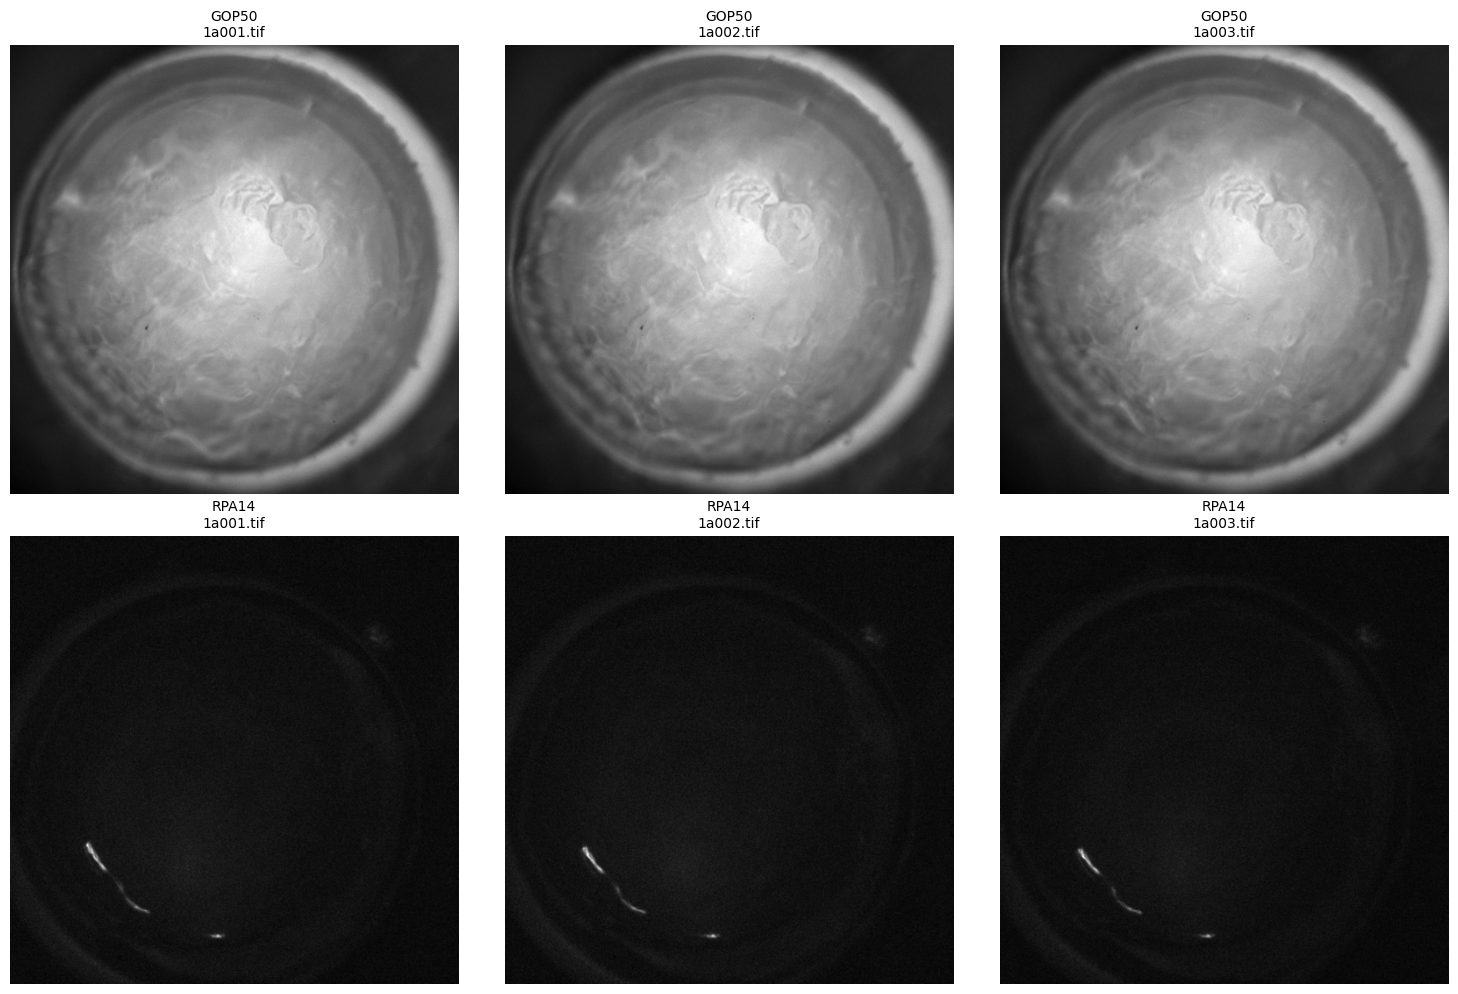

In [44]:
from tifffile import imread
import matplotlib.pyplot as plt
from natsort import natsorted

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

conditions = ["GOP50", "RPA14"]

for row_idx, condition in enumerate(conditions):

    subset = metadata_512_df[
        (metadata_512_df["condition"] == condition) &
        (metadata_512_df["replicate"] == 1) &
        (metadata_512_df["day"] == "D1")
    ].copy()

    # natural sort by filename
    subset = subset.iloc[
        natsorted(
            range(len(subset)),
            key=lambda i: subset.iloc[i]["file_name"]
        )
    ]

    selected = subset.head(3)

    for col_idx, (_, row) in enumerate(selected.iterrows()):

        img = imread(row["path"])

        axes[row_idx, col_idx].imshow(
            img,
            cmap="gray"
        )

        axes[row_idx, col_idx].set_title(
            f"{condition}\n{row['file_name']}",
            fontsize=10
        )

        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

They are pretty similar to the original pictures and I don't think shrinking them to 512 cost me any major biological information. However, here are some pictures from day 9 of the experiment where the worms are not in great condition. In this case the pathogen treated pictures look very grainy and I am having a hard time spotting the worm by eye. There is also a lot of background. The control pictures also don't look as good, this may be due to whatever happened on that speicific date. I might need to look out for outlier days where data doesn't seem very clear.

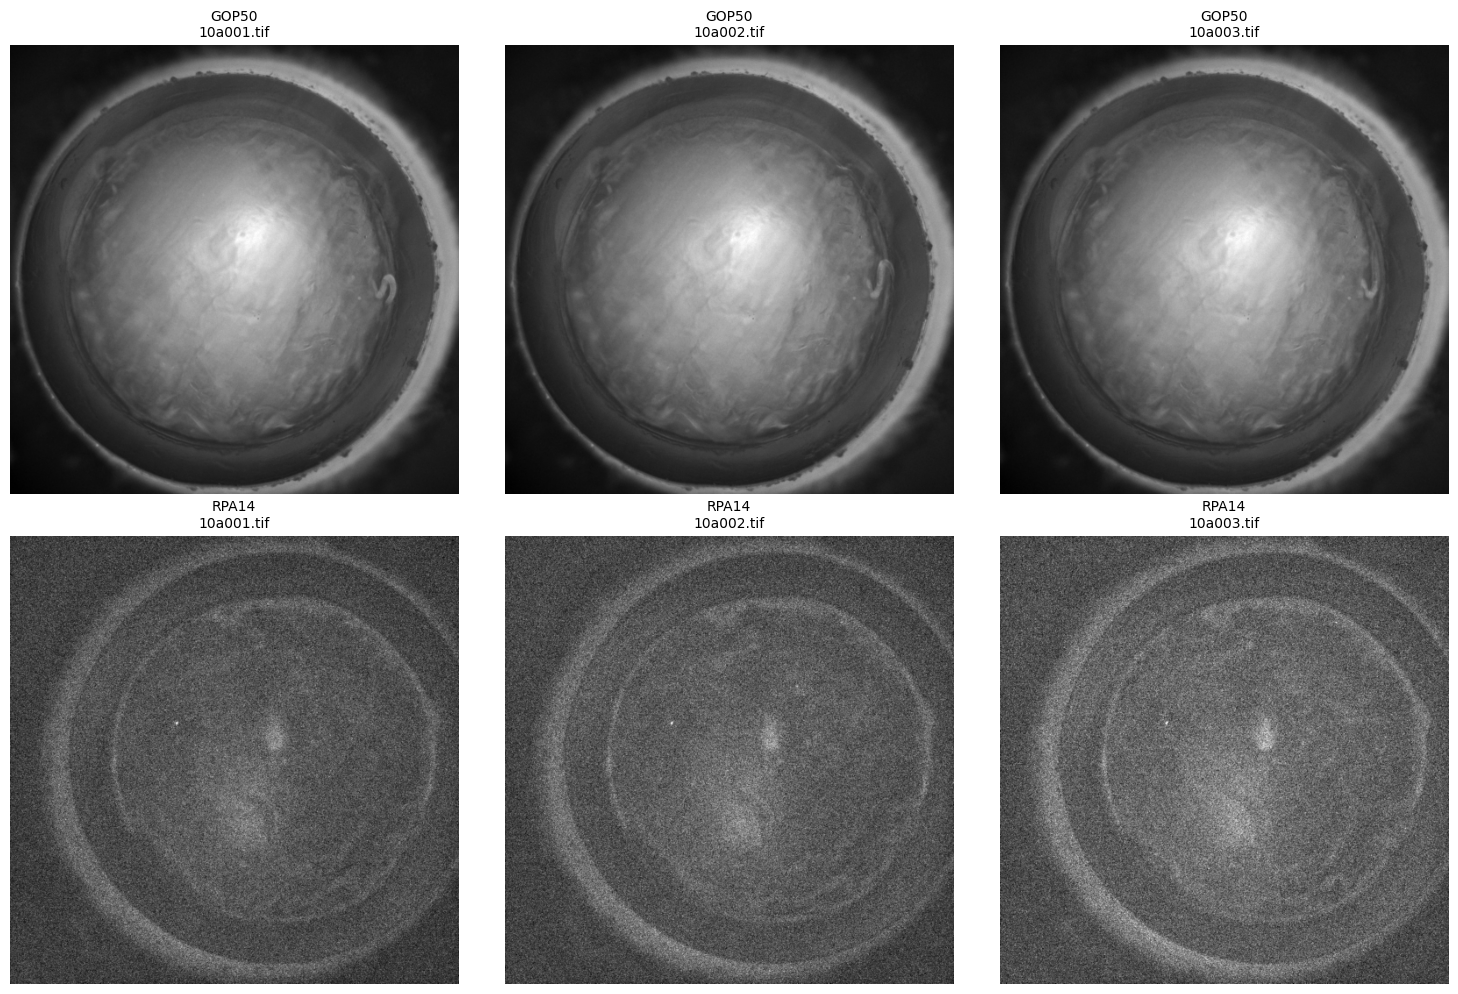

In [41]:
#show that images are still biologically relevant
from tifffile import imread
import matplotlib.pyplot as plt

#show 3 images from each condition
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

conditions = ["GOP50", "RPA14"]

for row_idx, condition in enumerate(conditions):

    #subset metadata
    subset = metadata_512_df[
        metadata_512_df["condition"] == condition
    ]

    #take first 3 rows
    selected = subset.head(3)

    for col_idx, (_, row) in enumerate(selected.iterrows()):

        #load image
        img = imread(row["path"])

        #plot image
        axes[row_idx, col_idx].imshow(
            img,
            cmap="gray"
        )

        axes[row_idx, col_idx].set_title(
            f"{condition}\n{row['file_name']}",
            fontsize=10
        )

        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

Based on the EDA I did for my project proposal and by looking at the differences in image categories, I know that the dataset histogram will be very skewed. I need to mask out the areas outside of the wells and also normalize the images. A circular mask works a lot better in this case. However as you can see from the RPA14 images above, sometimes the wells are not aligned exactly the same under the automized microscope, or there are location biases for some of the wells in the 96 well plate because the coordinates were not put in exactly. In these case we might lose some informationa and the worm might become out of frame. So I will use a loose circular mask rather than a tightly fitted mask.

First need to show the histogram before masking and normalization

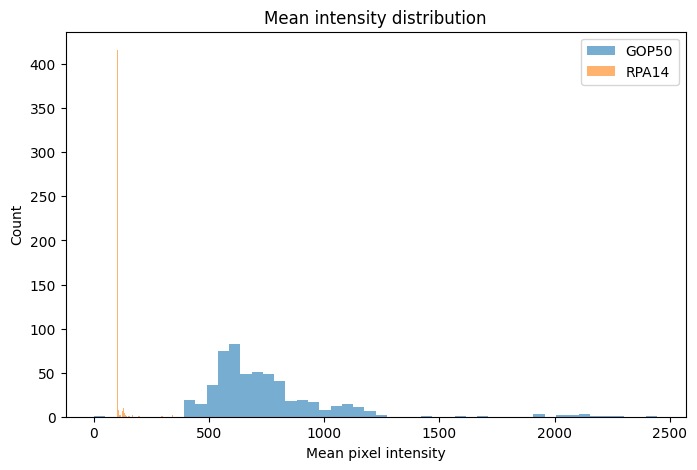

In [47]:
#histogram of 1000 images, entire dataset takes too long

from tifffile import imread
import matplotlib.pyplot as plt
import numpy as np

# random sample
sample_df = metadata_512_df.sample(
    1000,
    random_state=42
)

control_means = []
pathogen_means = []

for _, row in sample_df.iterrows():

    img = imread(row["path"])

    mean_intensity = img.mean()

    if row["condition"] == "GOP50":
        control_means.append(mean_intensity)

    else:
        pathogen_means.append(mean_intensity)

plt.figure(figsize=(8,5))

plt.hist(
    control_means,
    bins=50,
    alpha=0.6,
    label="GOP50"
)

plt.hist(
    pathogen_means,
    bins=50,
    alpha=0.6,
    label="RPA14"
)

plt.xlabel("Mean pixel intensity")
plt.ylabel("Count")
plt.title("Mean intensity distribution")

plt.legend()
plt.show()

In [4]:
#USE THIS CELL TO RESTART GOOGLE COLAB AND LOAD EVERYTHING BACK UP AGAIN

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tifffile import imread
import re

# Main folders
DRIVE_FOLDER = Path("/content/drive/MyDrive/Computer_Vision_Project_Data")
ORIGINAL_ROOT = DRIVE_FOLDER / "project"
RESIZED_ROOT = DRIVE_FOLDER / "project_512"

print("project exists:", ORIGINAL_ROOT.exists())
print("project_512 exists:", RESIZED_ROOT.exists())


#Reload data
metadata_512_df = pd.read_csv(
    RESIZED_ROOT / "image_metadata_512.csv"
)

metadata_512_df.head()

#check the paths
metadata_512_df["resized_exists"] = metadata_512_df["path"].apply(
    lambda x: Path(x).exists()
)

metadata_512_df["resized_exists"].value_counts()

Mounted at /content/drive
project exists: True
project_512 exists: True


,count
resized_exists,
True,11364


Like I guessed, the pixel histograms do not overlap between the categories at all and they are not normally distributed. After circular masking and normalizing I will save the images as numpy arrays instead of tiff because it takes too long to do anything still. I will also remove extreme intesity pictures.

My initial masking settings from the project proposal need to be re-asjusted since I changed the size of the images. 512 / 2048 = 0.25. New coordinates center=(240, 268)
radius=200

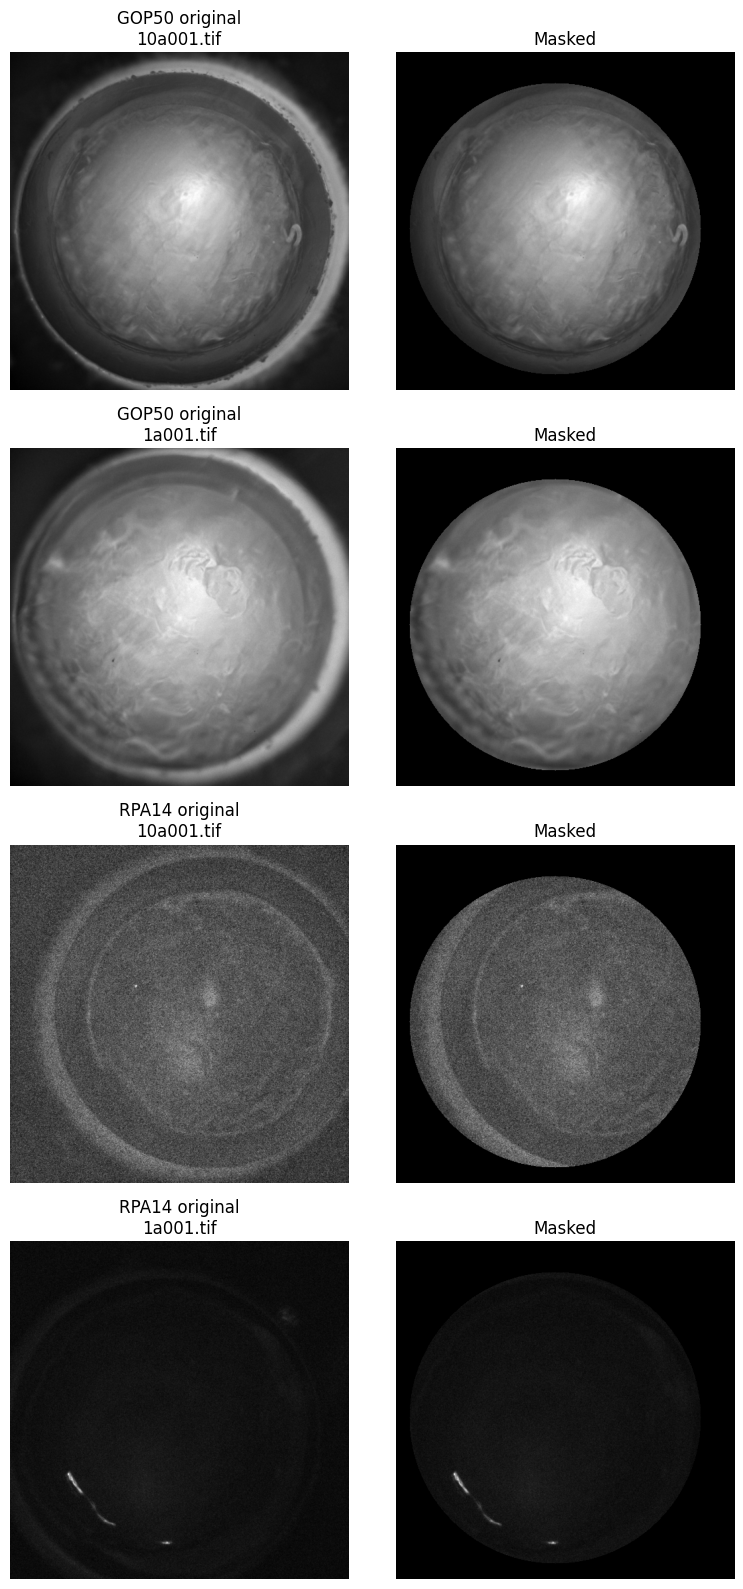

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread

def normalize_image(img):
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def mask_outside_well(img, center=(240, 268), radius=220):
    h, w = img.shape
    cx, cy = center

    Y, X = np.ogrid[:h, :w]
    mask = (X - cx)**2 + (Y - cy)**2 <= radius**2

    masked = img.copy()
    masked[~mask] = 0

    return masked, mask

# choose a few images to test
test_df = metadata_512_df[
    (metadata_512_df["replicate"] == 1) &
    (metadata_512_df["day"] == "D1") &
    (metadata_512_df["file_name"].isin(["1a001.tif", "10a001.tif"]))
].copy()

fig, axes = plt.subplots(len(test_df), 2, figsize=(8, 4 * len(test_df)))

for row_idx, (_, row) in enumerate(test_df.iterrows()):

    img = imread(row["path"])
    img_norm = normalize_image(img)

    img_masked, mask = mask_outside_well(
        img_norm,
        center=(240, 268),
        radius=220
    )

    axes[row_idx, 0].imshow(img_norm, cmap="gray")
    axes[row_idx, 0].set_title(f"{row['condition']} original\n{row['file_name']}")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(img_masked, cmap="gray")
    axes[row_idx, 1].set_title("Masked")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

Masking seems to work for most, except one well that's not centered. I will choose to pick the setting that works best with centralized wells. Can eliminate wells later if they are very off center.

I initially tried percentile clipping for normalization since there seem to be a lot of outliying pixels in this dataset, however percentile clipping was too extreme, and signal got distorted a bit for the pathogen pictures. Global percentile normalization was amplifying noise in the dim images, so I will use min max normalization instead.

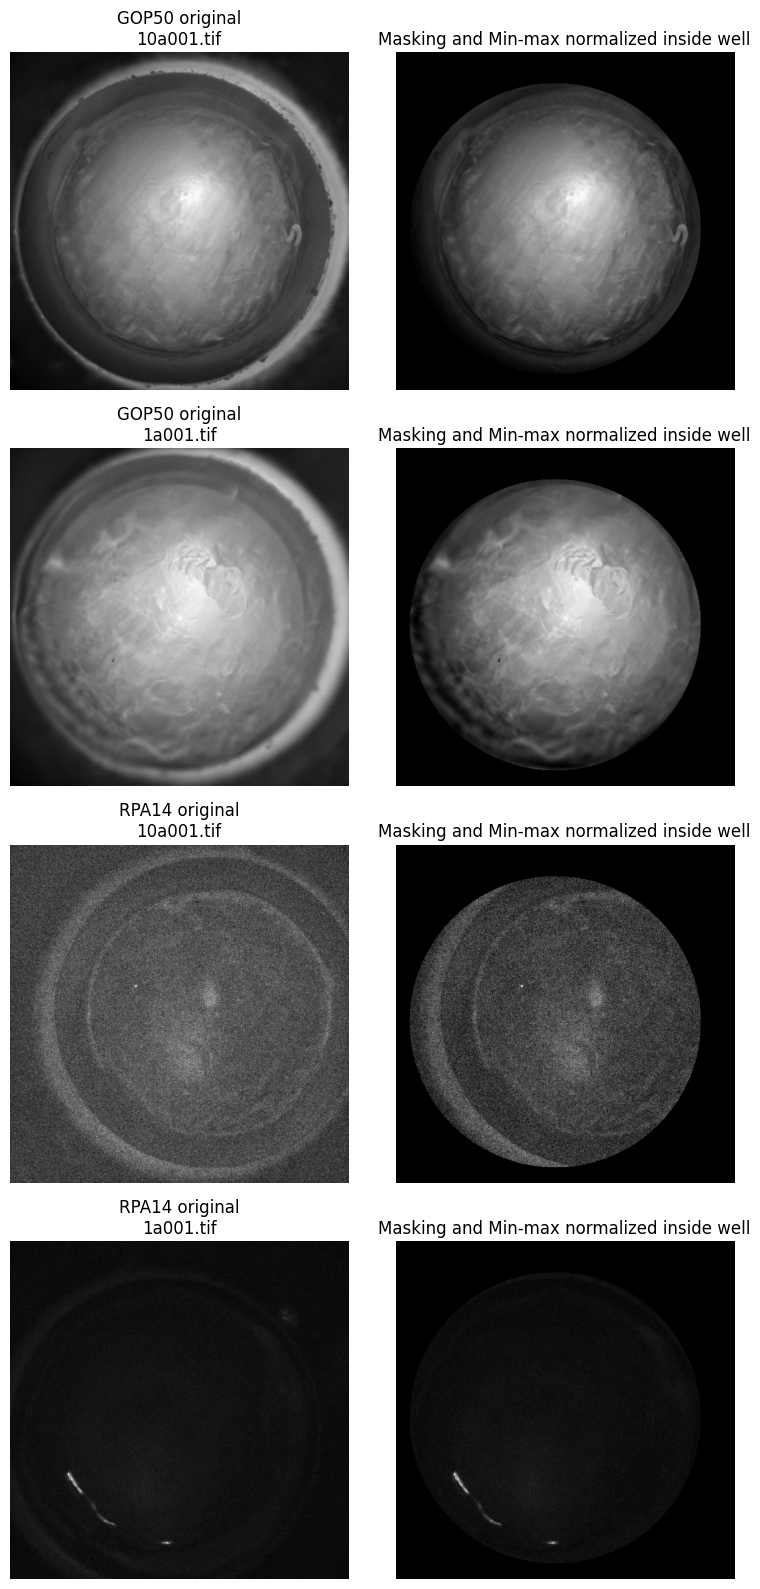

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread

def normalize_minmax(img):
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def make_well_mask(img_shape, center=(240, 268), radius=200):
    h, w = img_shape
    cx, cy = center

    Y, X = np.ogrid[:h, :w]
    mask = (X - cx)**2 + (Y - cy)**2 <= radius**2

    return mask

def apply_mask(img, mask):
    masked = img.copy()
    masked[~mask] = 0
    return masked

def normalize_minmax_inside_mask(img, mask):
    img = img.astype(np.float32)

    inside = img[mask]

    low = inside.min()
    high = inside.max()

    img_norm = (img - low) / (high - low + 1e-8)
    img_norm = np.clip(img_norm, 0, 1)
    img_norm[~mask] = 0

    return img_norm

# use same test images
test_df = metadata_512_df[
    (metadata_512_df["replicate"] == 1) &
    (metadata_512_df["day"] == "D1") &
    (metadata_512_df["file_name"].isin([
        "1a001.tif",
        "10a001.tif"
    ]))
].copy()

fig, axes = plt.subplots(
    len(test_df),
    2,
    figsize=(8, 4 * len(test_df))
)

for row_idx, (_, row) in enumerate(test_df.iterrows()):

    img = imread(row["path"])

    # make mask from raw image shape
    mask = make_well_mask(
        img.shape,
        center=(240, 268),
        radius=220
    )

    # basic min-max normalization for viewing only
    img_basic = normalize_minmax(img)

    #do mask and normalization
    img_processed = normalize_minmax_inside_mask(img, mask)

    axes[row_idx, 0].imshow(img_basic, cmap="gray")
    axes[row_idx, 0].set_title(
        f"{row['condition']} original\n{row['file_name']}"
    )
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(img_processed, cmap="gray")
    axes[row_idx, 1].set_title("Masking and Min-max normalized inside well")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

I will now mask and normalize the entire dataset and save the images in a numpy array format to be able to work with them more easily.

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
from tifffile import imread
from tqdm.notebook import tqdm

#using the previously defined functions make_well_mask and normalize_minmax_inside_mask

#output folder
PROJECT_512_ROOT = Path(
    "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512"
)

OUTPUT_FOLDER = PROJECT_512_ROOT / "processed_npy"

OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


#mask all images
sample_img = imread(metadata_512_df.iloc[0]["path"])

global_mask = make_well_mask(
    sample_img.shape,
    center=(240, 268),
    radius=200
)


#process all images
processed_metadata = []

for idx, row in tqdm(
    metadata_512_df.iterrows(),
    total=len(metadata_512_df)
):

    img_path = Path(row["path"])

    #load image
    img = imread(img_path)

    #preprocess
    img_processed = normalize_minmax_inside_mask(
        img,
        global_mask
    )

    #preserve folder structure
    relative_path = img_path.relative_to(PROJECT_512_ROOT)

    output_path = OUTPUT_FOLDER / relative_path.with_suffix(".npy")

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    #save numpy array
    np.save(
        output_path,
        img_processed.astype(np.float32)
    )

    #save metadata
    processed_metadata.append({
        "original_path": str(img_path),
        "processed_path": str(output_path),
        "condition": row["condition"],
        "replicate": row["replicate"],
        "label": row["label"],
        "day": row["day"],
        "file_name": row["file_name"]
    })

#save the metadata

processed_metadata_df = pd.DataFrame(
    processed_metadata
)

processed_metadata_df.to_csv(
    PROJECT_512_ROOT / "processed_metadata.csv",
    index=False
)

print("Done!")
print(f"Saved {len(processed_metadata_df)} processed arrays")

  0%|          | 0/11364 [00:00<?, ?it/s]

Done!
Saved 11364 processed arrays


In [3]:
# load and show the metadata for the processed npy arrays
from pathlib import Path
import pandas as pd


PROJECT_512_ROOT = Path(
    "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512"
)
PROCESSED_FOLDER = PROJECT_512_ROOT / "processed_npy"
PROCESSED_METADATA_PATH = PROJECT_512_ROOT / "processed_metadata.csv"

print("project_512 exists:", PROJECT_512_ROOT.exists())
print("processed_npy exists:", PROCESSED_FOLDER.exists())
print("processed metadata exists:", PROCESSED_METADATA_PATH.exists())
processed_metadata_df = pd.read_csv(PROCESSED_METADATA_PATH)

processed_metadata_df.head()

project_512 exists: True
processed_npy exists: True
processed metadata exists: True


,original_path,processed_path,condition,replicate,label,day,file_name
0,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10a001.tif
1,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10a002.tif
2,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10a003.tif
3,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10b001.tif
4,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10b002.tif


After pre-processing all these images with masking and normalization, here is what the histogram of pixel distribution looks like. Attempting to make a histogram using the entire dataset was taking a very long time (close to 2 hours) so I will show a histogram for a subset of 500 images.

  0%|          | 0/500 [00:00<?, ?it/s]

Images sampled: 500
Total pixels: 24950000
Min: 1.5371845e-05
Max: 1.0


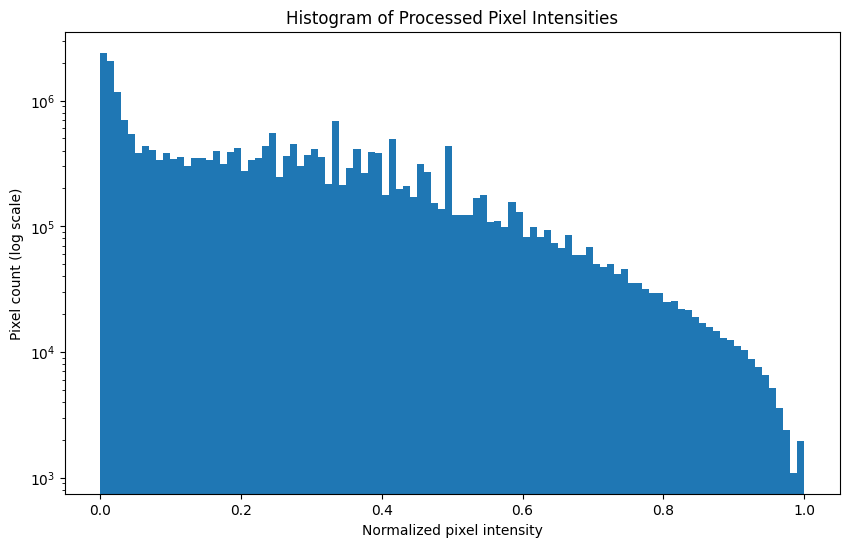

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm


#sample only a subset of images
N_IMAGES = 500   # try 100–500

sample_df = processed_metadata_df.sample(
    n=N_IMAGES,
    random_state=42
)

all_pixels = []

for path in tqdm(sample_df["processed_path"]):

    img = np.load(path)

    # use only pixels inside the well
    pixels = img[img > 0]

    #randomly sample pixels from each image
    #prevents giant arrays
    if len(pixels) > 50000:
        pixels = np.random.choice(
            pixels,
            size=50000,
            replace=False
        )

    all_pixels.append(pixels)

#combine
all_pixels = np.concatenate(all_pixels)

print("Images sampled:", N_IMAGES)
print("Total pixels:", len(all_pixels))
print("Min:", all_pixels.min())
print("Max:", all_pixels.max())

#histogram
plt.figure(figsize=(10, 6))

plt.hist(
    all_pixels,
    bins=100,
    log=True
)

plt.title("Histogram of Processed Pixel Intensities")
plt.xlabel("Normalized pixel intensity")
plt.ylabel("Pixel count (log scale)")

plt.show()

This histogram shows all the pixels in all categories, overall it looks like the nomalization and masking imporved things quite a bit but we need to group them by control/pathogen condition to see if there are major differences.

GOP50:   0%|          | 0/500 [00:00<?, ?it/s]

RPA14:   0%|          | 0/500 [00:00<?, ?it/s]

GOP50 pixels: 25000000
RPA14 pixels: 25000000


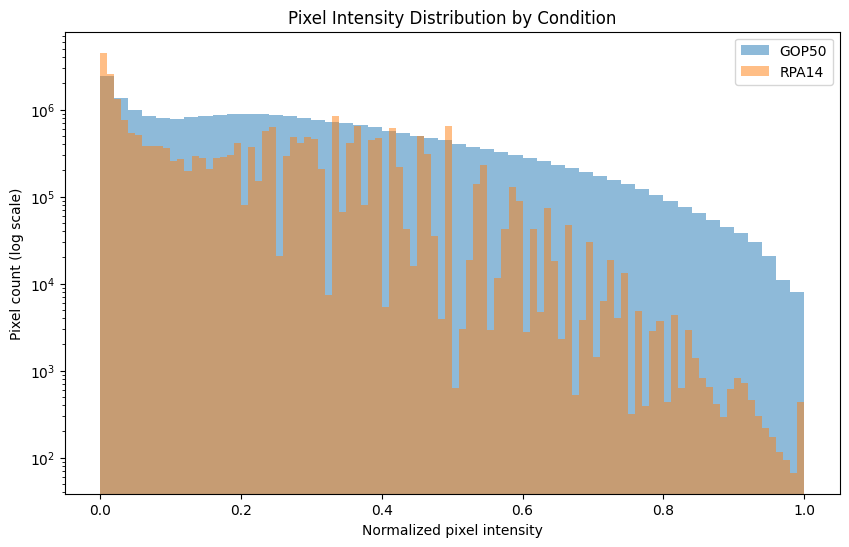

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

N_IMAGES = 500

#sample images from each group
gop50_df = processed_metadata_df[
    processed_metadata_df["condition"] == "GOP50"
].sample(n=N_IMAGES, random_state=42)

rpa14_df = processed_metadata_df[
    processed_metadata_df["condition"] == "RPA14"
].sample(n=N_IMAGES, random_state=42)

#store pixels separately
gop50_pixels = []
rpa14_pixels = []

# GOP50

for path in tqdm(gop50_df["processed_path"], desc="GOP50"):

    img = np.load(path)

    pixels = img[img > 0]

    #optional subsampling
    if len(pixels) > 50000:
        pixels = np.random.choice(
            pixels,
            size=50000,
            replace=False
        )

    gop50_pixels.append(pixels)

# RPA14

for path in tqdm(rpa14_df["processed_path"], desc="RPA14"):

    img = np.load(path)

    pixels = img[img > 0]

    if len(pixels) > 50000:
        pixels = np.random.choice(
            pixels,
            size=50000,
            replace=False
        )

    rpa14_pixels.append(pixels)

# combine arrays
gop50_pixels = np.concatenate(gop50_pixels)
rpa14_pixels = np.concatenate(rpa14_pixels)

print("GOP50 pixels:", len(gop50_pixels))
print("RPA14 pixels:", len(rpa14_pixels))


# plot
plt.figure(figsize=(10, 6))

plt.hist(
    gop50_pixels,
    bins=50,
    alpha=0.5,
    label="GOP50",
    log=True
)

plt.hist(
    rpa14_pixels,
    bins=100,
    alpha=0.5,
    label="RPA14",
    log=True
)

plt.xlabel("Normalized pixel intensity")
plt.ylabel("Pixel count (log scale)")
plt.title("Pixel Intensity Distribution by Condition")

plt.legend()

plt.show()

There seems to be still a bit of a difference between the two groups. It is significantly better than what we started with but there is still the possibility of the model learning pixel patterns or brightness differences and not meaningful differences. At this point this is probably the best we could do because the difference in fluorecence intensity is due to the fact that they used different reporters for OP50 and PA14.

# **Data Augmentation and Training**

Since that there is an obvious difference in brightness between groups its important to include brightness jitter and contrast jitter in data augmentation. I will only perform data augmentation on training data and not test data.

First we split the data into training, validation and test data.  

In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

#load processed metadata
processed_metadata_df = pd.read_csv(
    "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512/processed_metadata.csv"
)

#paths and labels
X_paths = processed_metadata_df["processed_path"].values
y = processed_metadata_df["label"].values

#train/validation/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_paths,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 7954
Validation: 1705
Test: 1705


Create TensorFlow loader

In [22]:
IMG_SIZE = 512
BATCH_SIZE = 16

def load_npy(path, label):
    def _load(path):
        path = path.decode("utf-8")
        img = np.load(path).astype(np.float32)
        img = np.expand_dims(img, axis=-1)  # shape: 512,512,1
        return img

    img = tf.numpy_function(_load, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 1))

    label = tf.cast(label, tf.float32)

    return img, label

Data augmentation: Using random flip, random rotation, random zoom, random contrast, rndom brightness, random contrast and gamma augmentation. Gamma augmentation the brightness relationship between dark and bright pixels in a nonlinear way so it might be especially useful in this situation where we have a lot of very dark and very light spots in the images.

In [21]:
import tensorflow as tf

# create layers ONCE
random_rotation = tf.keras.layers.RandomRotation(
    factor=(-0.05, 0.05)
)

random_zoom = tf.keras.layers.RandomZoom(
    height_factor=(-0.05, 0.05),
    width_factor=(-0.05, 0.05)
)

def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)

    img = random_rotation(img, training=True)
    img = random_zoom(img, training=True)

    img = tf.image.random_brightness(img, max_delta=0.08)
    img = tf.clip_by_value(img, 0.0, 1.0)   # IMPORTANT

    img = tf.image.random_contrast(img, lower=0.90, upper=1.10)
    img = tf.clip_by_value(img, 0.0, 1.0)   # IMPORTANT

    gamma = tf.random.uniform([], 0.90, 1.10)
    img = tf.image.adjust_gamma(img, gamma=gamma)

    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, label

In [9]:
#BUILD DATASETS
#create tensors before augmenting
#apply augmentation to train set

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train))
train_ds = train_ds.map(load_npy,num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment_image,num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_npy, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_npy, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Before doing anything else make sure that batching worked, the grayscale channel exists, and the images sizes are still correct (512,512)

In [10]:
for imgs, labels in train_ds.take(1):
    print(imgs.shape)   # should be (BATCH_SIZE, 512, 512, 1)
    print(labels.shape)
    print(imgs.dtype)
    print(labels[:10].numpy())

(16, 512, 512, 1)
(16,)
<dtype: 'float32'>
[1. 0. 0. 1. 0. 0. 0. 1. 1. 0.]


Now it's time to make a baseline CNN model before I move on to anything too complicated. This basic model is doing binary classification. 0 = GOP50
1 = RPA14.

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(512, 512, 1)),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [30]:
#compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 510, 510, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,865 (1.61 MB)

 Trainable params: 420,865 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

There are a lot more paramaters than what we started with but its not too many to handle and will be less liekly to crash google colab.

In [31]:
#add callbacks

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512/best_cnn_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

Directly training from drive is causing problems and taking very long so I will put the processed dataset into colab SSD and update my paths for batching

Need to copy things to SSD before every training session otherwise it's impossible to train model.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
!rsync -ah --info=progress2 \
"/content/drive/MyDrive/Computer_Vision_Project_Data/project_512/processed_npy/" \
"/content/processed_npy/"

#THIS TAKES 80 MINS EACH TIME YOU NEED TO RE-LOAD TO THE SSD

         11.92G 100%    4.26MB/s    0:44:30 (xfr#11364, to-chk=0/11429)


File numbers need to match to make sure everything is copied to the SSD ok.

In [5]:
!find /content/processed_npy -name "*.npy" | wc -l

11364


In [6]:
!find "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512/processed_npy" -name "*.npy" | wc -l

11364


In [7]:
processed_metadata_df["local_processed_path"] = processed_metadata_df["processed_path"].str.replace(
    "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512/processed_npy",
    "/content/processed_npy",
    regex=False
)

X_paths = processed_metadata_df["local_processed_path"].values
y = processed_metadata_df["label"].values

In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_paths, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [32]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train))
train_ds = train_ds.map(load_npy, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_npy, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_npy, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [34]:
#TRAIN THE BASIC MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.8084 - auc: 0.9080 - loss: 0.3707 - val_accuracy: 0.8880 - val_auc: 0.9743 - val_loss: 0.2150
Epoch 2/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8907 - auc: 0.9621 - loss: 0.2319 - val_accuracy: 0.8745 - val_auc: 0.9639 - val_loss: 0.2395
Epoch 3/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.8962 - auc: 0.9637 - loss: 0.2266 - val_accuracy: 0.8739 - val_auc: 0.9654 - val_loss: 0.2409
Epoch 4/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9037 - auc: 0.9694 - loss: 0.2150 - val_accuracy: 0.9308 - val_auc: 0.9896 - val_loss: 0.1610
Epoch 5/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9173 - auc: 0.9757 - loss: 0.1941 - val_accuracy: 0.9355 - val_auc: 0.9898 - val_loss: 0.1515
Epoch 6/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9223 - auc: 0.9782 - loss: 0.1872 - val_accuracy: 0.9355 - val_auc: 0.9886 - val_loss: 0.1466
Epoch 7/30
498/498 ━━━━━━━━━

It took 10 epochs for the model to complete its training. It was pretty fast.

In [35]:
test_results = model.evaluate(test_ds)

print(test_results)

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9384 - auc: 0.9890 - loss: 0.1485
[0.14846596121788025, 0.9384164214134216, 0.9889634847640991]


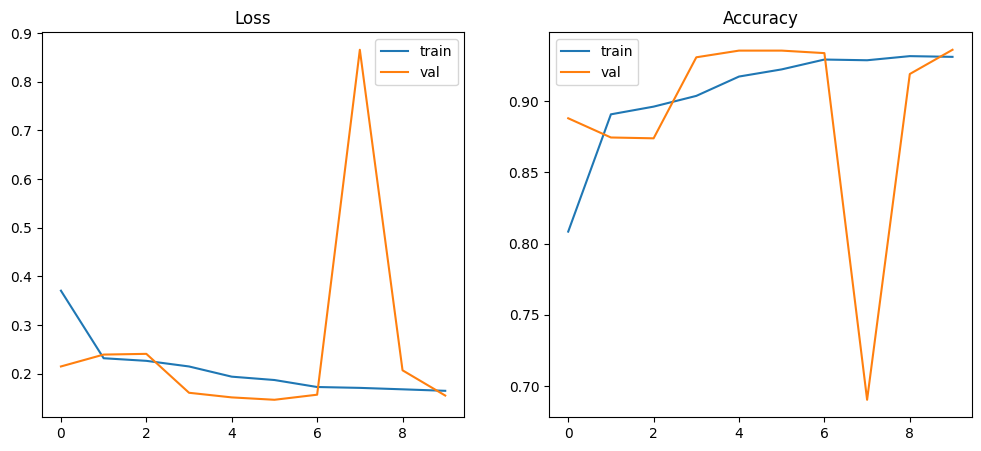

In [36]:
#plot curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

In [37]:
print("Train labels:", np.unique(y_train, return_counts=True))
print("Val labels:", np.unique(y_val, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))

Train labels: (array([0, 1]), array([4307, 3647]))
Val labels: (array([0, 1]), array([923, 782]))
Test labels: (array([0, 1]), array([923, 782]))


The model was able to learn. Accuracy: 0.9384 - auc: 0.9890 - loss: 0.1485. However, when we look at the loss curves there is a really weird dip on epoch 7. By the end of epoch 10,  both training and validation converged so there is no obvious overfitting. The spike is could be caused by a few unsual images. I am a bit suspicious of how fast and accurately it learned, it could be making decisions based on the patterns in brightness or background and not information on the worms.

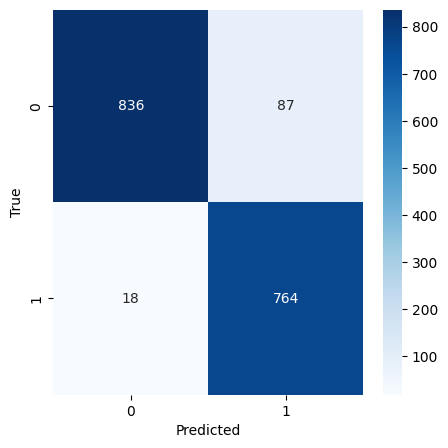

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

for imgs, labels in test_ds:

    preds = model.predict(imgs, verbose=0)

    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Confusion matrix also looks relatively ok. False positives: 87
False negatives: 18. The model is more likely to assign something as pathogen infected than not. So if we care about really high sensitivity this may be ok but there are also false positives. Another reason could be, older worms tend to get more colonization than younger worms, so it's possible that the some of the control fed worms might have a fluorescent signal due to control bacteria colonization. The dip could also be caused by discreptancies between the biological replicates, maybe the model is learning the patterns based on the biological replicate. We split the training data based on image path,the training dataset is balanced in terms of how many control and pathogen images there are but maybe the different treatment days are not represented well enough.

In [43]:
split_df = processed_metadata_df.copy()

split_df["split"] = "none"
split_df.loc[split_df["processed_path"].isin(X_train), "split"] = "train"
split_df.loc[split_df["processed_path"].isin(X_val), "split"] = "val"
split_df.loc[split_df["processed_path"].isin(X_test), "split"] = "test"

pd.crosstab(
    [split_df["condition"], split_df["replicate"], split_df["day"]],
    split_df["split"]
)

split                    none
condition replicate day      
GOP50     1         D1    288
                    D2    288
                    D3    288
                    D4    270
                    D5    270
                    D6    258
                    D7    249
                    D8    240
                    D9    234
          2         D1    279
                    D2    279
                    D3    270
                    D4    213
                    D5    159
                    D6    129
                    D7     99
                    D8     84
                    D9     78
          3         D1    288
                    D2    288
                    D3    288
                    D4    288
                    D5    255
                    D6    231
                    D7    195
                    D8    177
                    D9    168
RPA14     1         D1    288
                    D2    288
                    D3    282
                    D4    267
                    D5    195
                    D6    135
                    D7    105
                    D8     96
                    D9     84
          2         D1    288
                    D2    288
                    D3    288
                    D4    246
                    D5    216
                    D6    153
                    D7     84
                    D8     48
                    D9     24
          3         D1    288
                    D2    288
                    D3    288
                    D4    288
                    D5    186
                    D6    174
                    D7    132
                    D8    117
                    D9     75

We already knew that day 8 and day 9 had fewer representatives in the dataset so training set still looks balanced. However there are also 3 replicates of each worm taken back to back, so if some of these images are split into training and test they would be almost identical and this may be inflating my accurracy. Model might benefit from only using one image per worm. Or I could also train based on replicates 1 and 2 and see if it could perfom well on replicate 3. If there is real learning it should be able to recognize replicate 3 images just as well.

I am using replicates 1 and 2 for training, and replicate 3 for validation and test (50% for validation, 50% for test, test dataset has not been seen by model). Augmentation was only done on the training dataset.

In [44]:
# SPLIT BY REPLICATE
#Train = Rep1 + Rep2
#Test/Val = Rep3


#make sure replicate column is integer
processed_metadata_df["replicate"] = (
    processed_metadata_df["replicate"].astype(int)
)


#replicate 1 + 2

train_df = processed_metadata_df[
    processed_metadata_df["replicate"].isin([1, 2])
].copy()


#replicate 3

holdout_df = processed_metadata_df[
    processed_metadata_df["replicate"] == 3
].copy()


#split replicate 3 into validation + test

from sklearn.model_selection import train_test_split

val_df, test_df = train_test_split(
    holdout_df,
    test_size=0.5,
    random_state=42,
    stratify=holdout_df["label"]
)



X_train = train_df["processed_path"].values
y_train = train_df["label"].values

X_val = val_df["processed_path"].values
y_val = val_df["label"].values

X_test = test_df["processed_path"].values
y_test = test_df["label"].values


#check if it worked
print("TRAIN replicates:")
print(train_df["replicate"].value_counts())

print("\nVAL replicates:")
print(val_df["replicate"].value_counts())

print("\nTEST replicates:")
print(test_df["replicate"].value_counts())

print("\nTrain labels:")
print(np.unique(y_train, return_counts=True))

print("\nVal labels:")
print(np.unique(y_val, return_counts=True))

print("\nTest labels:")
print(np.unique(y_test, return_counts=True))

TRAIN replicates:
replicate
1    4125
2    3225
Name: count, dtype: int64

VAL replicates:
replicate
3    2007
Name: count, dtype: int64

TEST replicates:
replicate
3    2007
Name: count, dtype: int64

Train labels:
(array([0, 1]), array([3975, 3375]))

Val labels:
(array([0, 1]), array([1089,  918]))

Test labels:
(array([0, 1]), array([1089,  918]))


In [45]:
#rebuild dataset again
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(
    len(X_train),
    seed=42,
    reshuffle_each_iteration=True
)

train_ds = train_ds.map(
    load_npy,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    augment_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#validation
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(
    load_npy,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#test
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(
    load_npy,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [46]:
#TRAIN THE BASIC MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.9038 - auc: 0.9696 - loss: 0.2227 - val_accuracy: 0.9736 - val_auc: 0.9963 - val_loss: 0.0844
Epoch 2/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.9106 - auc: 0.9721 - loss: 0.2133 - val_accuracy: 0.8465 - val_auc: 0.9370 - val_loss: 0.4767
Epoch 3/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.9084 - auc: 0.9726 - loss: 0.2111 - val_accuracy: 0.9781 - val_auc: 0.9976 - val_loss: 0.0759
Epoch 4/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.9120 - auc: 0.9719 - loss: 0.2151 - val_accuracy: 0.9631 - val_auc: 0.9955 - val_loss: 0.1045
Epoch 5/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9184 - auc: 0.9765 - loss: 0.1950 - val_accuracy: 0.9761 - val_auc: 0.9976 - val_loss: 0.0741
Epoch 6/30
460/460 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9129 - auc: 0.9743 - loss: 0.2038 - val_accuracy: 0.8934 - val_auc: 0.9672 - val_loss: 0.3030
Epoch 7/30
460/460 ━━━━━━━━

In [47]:
test_results = model.evaluate(test_ds)

print(test_results)

126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9726 - auc: 0.9978 - loss: 0.0728
[0.07282558083534241, 0.9725959300994873, 0.9978028535842896]


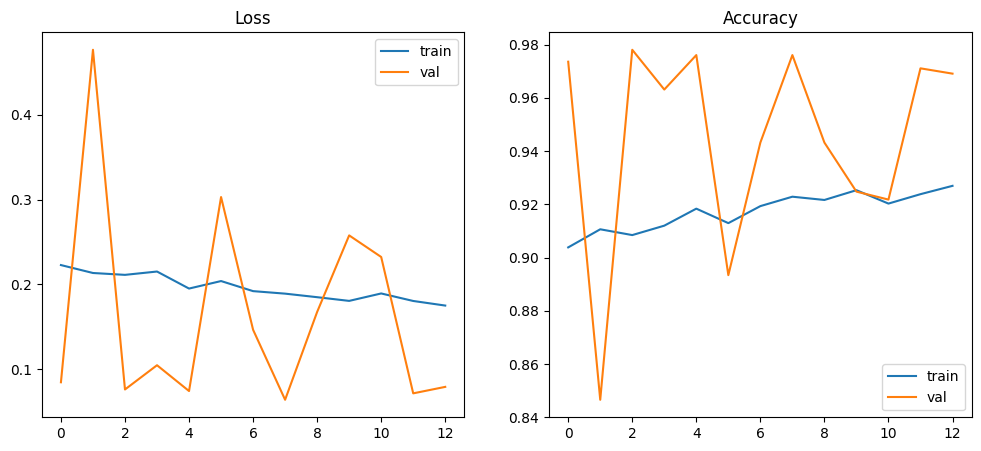

In [48]:
#plot curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

It took 13 epoch instead of 10 for this model to learn. Validation loss and accuracy is a lot more variable than the previous model but the overall accuracy is very high. The very first epoch starts with a high accuracy though which is a bit suspicious. Training loss is decreasing as expeccting and training and valisation accuracy are both increasing as expected.

Now I am going to only include 1 image per worm in my dataset. We will lose some data this way but it may be a good idea to not over populate the dataset with repeat images.

In [9]:
print(processed_metadata_df.columns.tolist())
processed_metadata_df.head()

['original_path', 'processed_path', 'condition', 'replicate', 'label', 'day', 'file_name', 'local_processed_path']


,original_path,processed_path,condition,replicate,label,day,file_name,local_processed_path
0,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10a001.tif,/content/processed_npy/GOP50_RPA14_N2 - Pooled...
1,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10a002.tif,/content/processed_npy/GOP50_RPA14_N2 - Pooled...
2,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10a003.tif,/content/processed_npy/GOP50_RPA14_N2 - Pooled...
3,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10b001.tif,/content/processed_npy/GOP50_RPA14_N2 - Pooled...
4,/content/drive/MyDrive/Computer_Vision_Project...,/content/drive/MyDrive/Computer_Vision_Project...,GOP50,1,0,D1,10b002.tif,/content/processed_npy/GOP50_RPA14_N2 - Pooled...


1a001, 1a002, and 1a003 are the consecutive images of the same worm

In [10]:
#only include one image per worm in dataset
import re

df = processed_metadata_df.copy()

# extract worm identity
df["worm_base"] = df["file_name"].str.extract(r"^(\d+[a-zA-Z])")

df["worm_id"] = (
    df["condition"].astype(str) + "_" +
    df["replicate"].astype(str) + "_" +
    df["day"].astype(str) + "_" +
    df["worm_base"].astype(str)
)

#randomly keep ONE image per worm
df_one_per_worm = (
    df.sample(frac=1, random_state=42)
      .drop_duplicates("worm_id")
      .reset_index(drop=True)
)

print("Original images:", len(df))
print("One image per worm:", len(df_one_per_worm))

df_one_per_worm[
    ["condition", "replicate", "day", "file_name", "worm_id"]
].head(20)

Original images: 11364
One image per worm: 3788


,condition,replicate,day,file_name,worm_id
0,GOP50,1,D1,2b003.tif,GOP50_1_D1_2b
1,GOP50,3,D2,11e001.tif,GOP50_3_D2_11e
2,GOP50,1,D1,6c003.tif,GOP50_1_D1_6c
3,RPA14,1,D4,10c001.tif,RPA14_1_D4_10c
4,GOP50,2,D1,10h002.tif,GOP50_2_D1_10h
5,RPA14,2,D4,2d003.tif,RPA14_2_D4_2d
6,GOP50,1,D5,1f002.tif,GOP50_1_D5_1f
7,GOP50,3,D7,12a002.tif,GOP50_3_D7_12a
8,GOP50,2,D4,11f002.tif,GOP50_2_D4_11f
9,GOP50,1,D4,12c003.tif,GOP50_1_D4_12c


Only including reps1 and 2 for training, and rep 3 for test. I am also creating validation from reps 1 and 2 as well instead of splitting rep3 for validation and test

In [11]:
#for train and test
train_df = df_one_per_worm[df_one_per_worm["replicate"].isin([1, 2])].copy()
test_df = df_one_per_worm[df_one_per_worm["replicate"] == 3].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 2450
Test size: 1338


In [12]:
#for validation
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 1960
Val: 490
Test: 1338


In [14]:
print("TRAIN")
print(train_df["label"].value_counts())

print("\nVAL")
print(val_df["label"].value_counts())

print("\nTEST")
print(test_df["label"].value_counts())

TRAIN
label
0    1060
1     900
Name: count, dtype: int64

VAL
label
0    265
1    225
Name: count, dtype: int64

TEST
label
0    726
1    612
Name: count, dtype: int64


Image number went down to aroun 3k from 11k because we got rid of 66% of images. The classes still look balanced

In [15]:
#build the arrays ffrom ssd
X_train = train_df["local_processed_path"].values
y_train = train_df["label"].values

X_val = val_df["local_processed_path"].values
y_val = val_df["label"].values

X_test = test_df["local_processed_path"].values
y_test = test_df["label"].values

In [17]:
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

In [23]:
#train dataset

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

train_ds = (train_ds.shuffle(len(X_train)).map(load_npy, num_parallel_calls=AUTOTUNE).map(augment_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [24]:
#validation dataset
val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_ds = (
    val_ds
    .map(load_npy, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [25]:
#test dataset
test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_ds = (
    test_ds
    .map(load_npy, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [27]:
#verfiy the tensors
import numpy as np
import tensorflow as tf
for imgs, labels in train_ds.take(1):

    print("Shape:", imgs.shape)

    print("Min:", tf.reduce_min(imgs).numpy())
    print("Max:", tf.reduce_max(imgs).numpy())

    print(
        "Contains NaN:",
        tf.math.reduce_any(tf.math.is_nan(imgs)).numpy()
    )

Shape: (16, 512, 512, 1)
Min: 0.0
Max: 1.0
Contains NaN: False


I am going to use the same basic CNN model as before and see how well it does when i train it differently.

In [28]:
#MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(512, 512, 1)),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [29]:
#COMPILE MODEL

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,865 (1.61 MB)

 Trainable params: 420,865 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#add callbacks

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512/best_cnn_model.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True
    )
]

In [32]:
#TRAIN AGAIN
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 31s 152ms/step - accuracy: 0.6046 - auc: 0.6835 - loss: 0.6643 - val_accuracy: 0.8102 - val_auc: 0.9348 - val_loss: 0.5792
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8122 - auc: 0.9040 - loss: 0.3923 - val_accuracy: 0.8694 - val_auc: 0.9752 - val_loss: 0.2528
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.8474 - auc: 0.9353 - loss: 0.3112 - val_accuracy: 0.8265 - val_auc: 0.9453 - val_loss: 0.3321
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.8469 - auc: 0.9374 - loss: 0.3010 - val_accuracy: 0.8714 - val_auc: 0.9652 - val_loss: 0.2570
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8730 - auc: 0.9519 - loss: 0.2799 - val_accuracy: 0.8959 - val_auc: 0.9690 - val_loss: 0.2392
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8617 - auc: 0.9453 - loss: 0.2769 - val_accuracy: 0.8776 - val_auc: 0.9737 - val_loss: 0.2311
Epoch 7/30
123/123 ━━━━━━━━━━━━━

In [33]:
test_results = model.evaluate(test_ds)

print(test_results)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9806 - auc: 0.9982 - loss: 0.0608
[0.06080345809459686, 0.980567991733551, 0.9981926679611206]


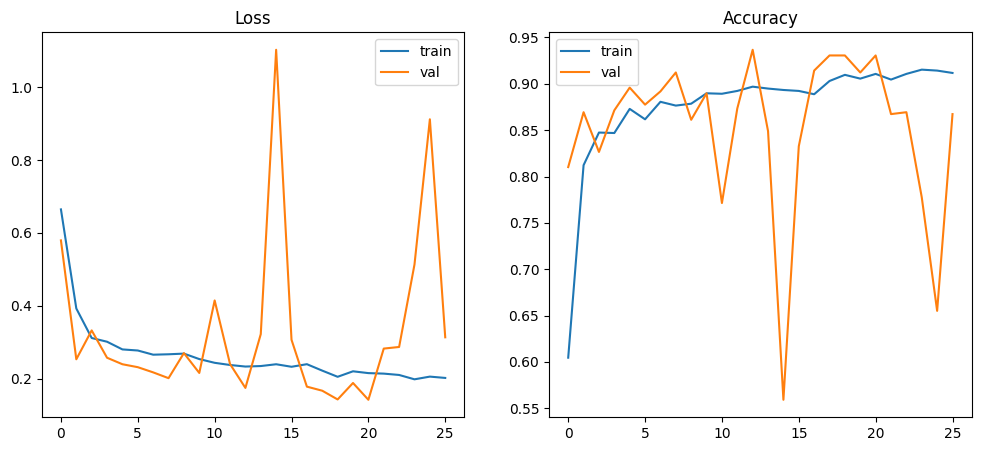

In [34]:
#plot curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

There is a lot more noise in this model but I think what we are seeing is more realistic. It's taking 26 epochs to learn and the model accuracy starts from 0.6 and increases to 0.9 instead of starting off at 0.9. Starting off with a very high accuracy made me think that it was immediately picking up on the brigtness differences between the different classes of images. After getting rid of the repetitive worm images, the dataset has gotten pretty small. Small validation set might be causing these spikes. Trainin loss is decreasing and trainin accuracy is increasing as expected. Validation loss and accuracy are both very volatile, but validation data set is down to ~500 images which is very small. Training data had augmentation, but validation doesn't.

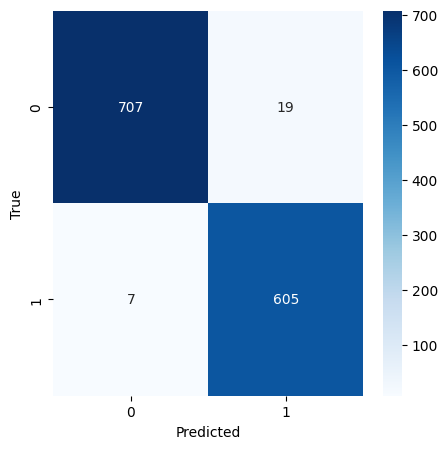

In [35]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

for imgs, labels in test_ds:

    preds = model.predict(imgs, verbose=0)

    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

False positives and false negatives are much smaller compared to the first model with random data splitting. The accuracy is very high 0.98. There may be a lot of spikes in validation but the model is able to assign things correctly.

Now I am going to try using efficient net to see if we can improve things


In [36]:
import tensorflow as tf

IMG_SIZE = 512

efficient_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

efficient_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [45]:
inputs = tf.keras.Input(shape=(512, 512, 1))

x = tf.keras.layers.Lambda(
    lambda img: tf.image.grayscale_to_rgb(img)
)(inputs)

x = efficient_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

eff_model = tf.keras.Model(inputs, outputs)

In [46]:
#compile
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [47]:
#callbacks
callbacks_eff = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/Computer_Vision_Project_Data/project_512/best_efficientnet_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

In [48]:
history_eff = eff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_eff
)

Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 53s 257ms/step - accuracy: 0.5255 - auc: 0.5187 - loss: 0.7484 - val_accuracy: 0.5408 - val_auc: 0.5000 - val_loss: 0.6898
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.5097 - auc: 0.5061 - loss: 0.7287 - val_accuracy: 0.5408 - val_auc: 0.5000 - val_loss: 0.6900
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.5265 - auc: 0.5270 - loss: 0.7205 - val_accuracy: 0.5408 - val_auc: 0.5000 - val_loss: 0.6902
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.5281 - auc: 0.5232 - loss: 0.7231 - val_accuracy: 0.5408 - val_auc: 0.5000 - val_loss: 0.6912
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.5265 - auc: 0.5091 - loss: 0.7256 - val_accuracy: 0.5408 - val_auc: 0.6396 - val_loss: 0.6914
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.5122 - auc: 0.4953 - loss: 0.7320 - val_accuracy: 0.5408 - val_auc: 0.5000 - val_loss: 0.6916


In [49]:
test_results = eff_model.evaluate(test_ds)

print(test_results)

84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5426 - auc: 0.5000 - loss: 0.6893
[0.6892960667610168, 0.5426008701324463, 0.5]


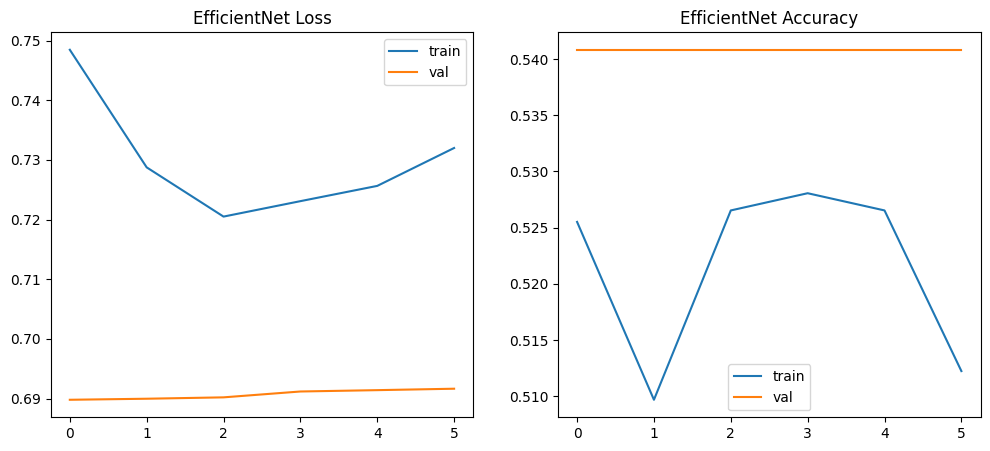

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# loss
plt.subplot(1,2,1)
plt.plot(history_eff.history["loss"], label="train")
plt.plot(history_eff.history["val_loss"], label="val")
plt.title("EfficientNet Loss")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history_eff.history["accuracy"], label="train")
plt.plot(history_eff.history["val_accuracy"], label="val")
plt.title("EfficientNet Accuracy")
plt.legend()

plt.show()

This model is not learning at all and is unable to discriminate between classes. I will remove the image weights from the model to see if this improves anything. The images efficientNet is trained on is probably useless in this case because they are everyday items like dogs and cars. Microscopy images are nothing like those everyday ites so I want the model to learn the weights based on my dataset.

In [51]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(512, 512, 3)
)

base_model.trainable = True

inputs = tf.keras.Input(shape=(512, 512, 1))

x = tf.keras.layers.Lambda(
    lambda img: tf.image.grayscale_to_rgb(img)
)(inputs)

x = base_model(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

eff_model = tf.keras.Model(inputs, outputs)

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [52]:
history_eff = eff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_eff
)

Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 157s 579ms/step - accuracy: 0.7367 - auc: 0.8082 - loss: 0.5568 - val_accuracy: 0.4592 - val_auc: 0.5000 - val_loss: 0.6962
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.8036 - auc: 0.8956 - loss: 0.4083 - val_accuracy: 0.5408 - val_auc: 0.5513 - val_loss: 0.6896
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.8327 - auc: 0.9160 - loss: 0.3727 - val_accuracy: 0.4592 - val_auc: 0.6509 - val_loss: 0.8005
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.8245 - auc: 0.9201 - loss: 0.3598 - val_accuracy: 0.4592 - val_auc: 0.7431 - val_loss: 0.8330
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.8520 - auc: 0.9359 - loss: 0.3238 - val_accuracy: 0.7449 - val_auc: 0.9630 - val_loss: 0.6670
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.8592 - auc: 0.9404 - loss: 0.3081 - val_accuracy: 0.8347 - val_auc: 0.9726 - val_loss: 0.3562
Epoch 7/30
123/123 ━━━━━━━

In [53]:
test_results = eff_model.evaluate(test_ds)

print(test_results)

84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9768 - auc: 0.9961 - loss: 0.0743
[0.0742725282907486, 0.9768310785293579, 0.9961063265800476]


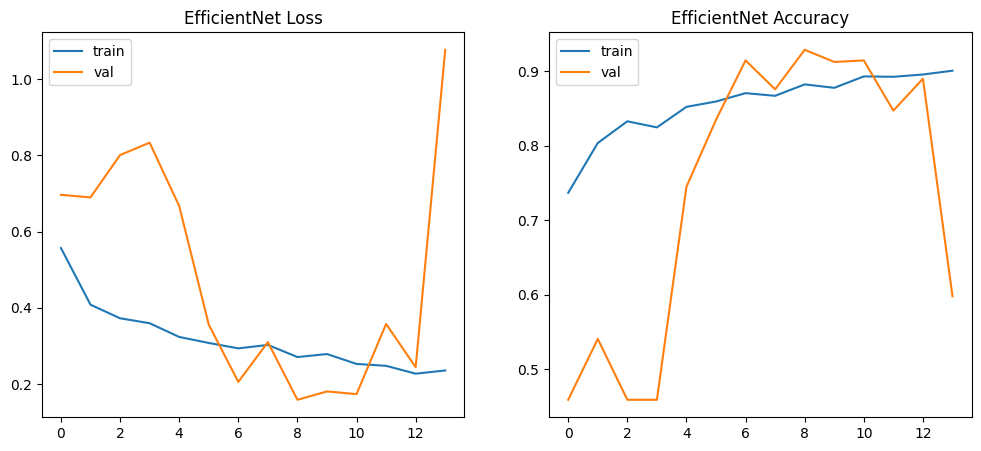

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# loss
plt.subplot(1,2,1)
plt.plot(history_eff.history["loss"], label="train")
plt.plot(history_eff.history["val_loss"], label="val")
plt.title("EfficientNet Loss")
plt.legend()

# accuracy
plt.subplot(1,2,2)
plt.plot(history_eff.history["accuracy"], label="train")
plt.plot(history_eff.history["val_accuracy"], label="val")
plt.title("EfficientNet Accuracy")
plt.legend()

plt.show()

Now the efficient net model is learning. It ends up being overfit in the end though. It learns for a while and then it probably starts picking up patterns based on background on contrast. Validation accuracy gets higher than the best CNN model before it drisctically drops down. This model could probably benefit from early stopping around epochs 10-12. The efficient net took much longer the train and is more complex but the best CNN model performs similary and doesn't become overfit in the end. Also the efficent net is more compuationally complex and expensive so using the CNN is still probbaly the better option.

# **Conclusion**
This dataset had a lot of class bias and pre-processing was very important to make sure that the model was not recognizing the background brightness. Both min-max normalization and making of the outer rim of the images worked really well and made the dataset workable.

One of the biggest challenges in this project was working with images that were loaded onto google drive. This was my first experience with using cloud images with google colab and it was much slower than it would have been if I had chosen to use the data in my local disk. I decided on using google colab because I wasn't sure my computer had enough computational power, but even working with images that were on the cloud slowed things down significantly (or loading them onto the cloud takes many many hours). It was very important to load the dataset onto colab SSD. I might have saved myself more time if I had done the preprocessing with my computer with the data on my hard drive.  

Overall, the biological context mattered a lot in this project. Biological replicates, along with different treatment days, introduced substantial variability within the dataset. The way I split up the training, validation and test data really effected how well the models performed. After cleaning out the repeated worm picture, the dataset ended up being quite small which contributed to noise.

In conclusion,a simple CNN performed better than efficientNet. Since the dataset was small and noisy, any model that instantly had an accuracy of 0.9 made me think that it was leaning the noise in the pictures instead of real biological differences. The best CNN model had a data split of : rep1 +2 for training and validation, rep 3 for test. This model increased its initial accuracy from 0.6 to 0.98 and showed that it was actually learning. Valdidation loss and accuracy was very variable but this was probably due to the fact that we didn't have many images for the validation dataset (~500).  In the end the CNN was simpler and performed better, and I did not need the complexity of EfficientNet. EfficientNet did not even learn at first with its default settings. This is not that surprising since microscopy images are very different from day to day images efficientNet was trained on. Making effientNet calculate the weights based on my data helped it learn better but the model ended up being over fit.

**What I would do differently:** I picked this dataset because I have a lot of domain knowledge in the area and this model could have potentially helped me in my own work. However, the quality of the dataset was not great, and I overlooked this fact due to my niche interest in this area. The dataset would have been much more useful if they had used more types of fluorescently tagged bacteria that resulted in in-between phenotypes instead of having binary results. With the current data, the most you could do is binary classification, which is rarely the case in a real life experiment. If they had included images with more magnification and multiple infection profiles, then I could have also done some segmentation or tried to pinpoint the exact location on the gut colonization instead of doing binary classification. The dataset also needed to be pre-processed very heavily and I would pay more attention to that in the future. For my future CV-projects I would probably pick a well known dataset that's been used many times for other CV-tasks instead of finding a scientific dataset wasn't initially designed for cv-tasks.

# **References**